# Step 0: Data Ingestion + EDA

**Goal:** Load data, understand structure, visualize trajectories

**Tasks:**
- [x] Load all 100 batches into unified structure
- [ ] Document batch lengths, sampling rates
- [ ] Identify missing values, anomalies
- [ ] Plot representative trajectories per control mode (DO2, Fs, P)
- [ ] Compute final P distribution per control mode

In [38]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.data_loader import load_batches, get_batch_info, get_final_penicillin, load_statistics

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Data

In [39]:
# Load all batches
batches = load_batches()
print(f"Loaded {len(batches)} batches")

# Show sample batch
batches[1].head()

Loaded 100 batches


,time,Fg,RPM,Fs,Fa,Fb,Fc,Fh,Fw,pressure,...,NH3_shots,Viscosity_offline,fault_ref,control_ref,1- No Raman spec,1-Raman spec recorded,batch_id,2-PAT control(PAT_ref:PAT ref),Batch ID,Fault flag
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,0,NaN,0,0,1,1,1,0,0.0,0.0
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,0,NaN,0,0,1,1,1,0,0.0,0.0
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,0,NaN,0,0,1,1,1,0,0.0,0.0
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,0,NaN,0,0,1,1,1,0,0.0,0.0
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,0,4.083,0,0,1,1,1,0,0.0,0.0


In [41]:
batches[1].columns

Index(['time', 'Fg', 'RPM', 'Fs', 'Fa', 'Fb', 'Fc', 'Fh', 'Fw', 'pressure',
       'Fremoved', 'S', 'DO2', 'P', 'V', 'Wt', 'pH', 'T', 'Q', 'CO2outgas',
       'Fpaa', 'PAA_offline', 'Foil', 'NH3_offline', 'OUR', 'O2', 'P_offline',
       'X_offline', 'CER', 'NH3_shots', 'Viscosity_offline', 'fault_ref',
       'control_ref', '1- No Raman spec', ' 1-Raman spec recorded', 'batch_id',
       '2-PAT control(PAT_ref:PAT ref)', 'Batch ID', 'Fault flag'],
      dtype='str')

In [19]:
# Get batch info summary
batch_info = get_batch_info(batches)
batch_info.head(10)

,batch_id,length,duration_h,control_mode,is_fault,p_conc
0,1,1130,225.8,recipe,False,29.3730
1,2,1150,229.8,recipe,False,30.4160
2,3,1390,277.8,recipe,False,17.4280
3,4,1150,229.8,recipe,False,15.1070
4,5,895,178.8,recipe,False,28.1720
5,6,1150,229.8,recipe,False,13.3660
6,7,1160,231.8,recipe,False,29.4160
7,8,1150,229.8,recipe,False,34.5080
8,9,1260,251.8,recipe,False,6.6957
9,10,1150,229.8,recipe,False,15.4110


## 2. Batch Lengths and Sampling Rates

In [20]:
# Summary statistics by control mode
batch_info.groupby('control_mode')[['length', 'duration_h']].describe().round(2)

length                                                     \
              count     mean     std     min      25%     50%      75%   
control_mode                                                             
apc            30.0  1123.33   76.76   835.0  1131.25  1150.0  1150.00   
fault          10.0  1152.50   74.69  1050.0  1131.25  1150.0  1150.00   
operator       30.0  1146.17   73.03   965.0  1150.00  1150.0  1153.75   
recipe         30.0  1144.17  121.50   895.0  1132.50  1150.0  1150.00   

                     duration_h                                               \
                 max      count    mean    std    min     25%    50%     75%   
control_mode                                                                   
apc           1205.0       30.0  224.47  15.35  166.8  226.05  229.8  229.80   
fault         1290.0       10.0  230.30  14.94  209.8  226.05  229.8  229.80   
operator      1310.0       30.0  229.03  14.61  192.8  229.80  229.8  230.55   
recipe        1450.0       30.0  228.63  24.30  178.8  226.30  229.8  229.80   

                     
                max  
control_mode         
apc           240.8  
fault         257.8  
operator      261.8  
recipe        289.8

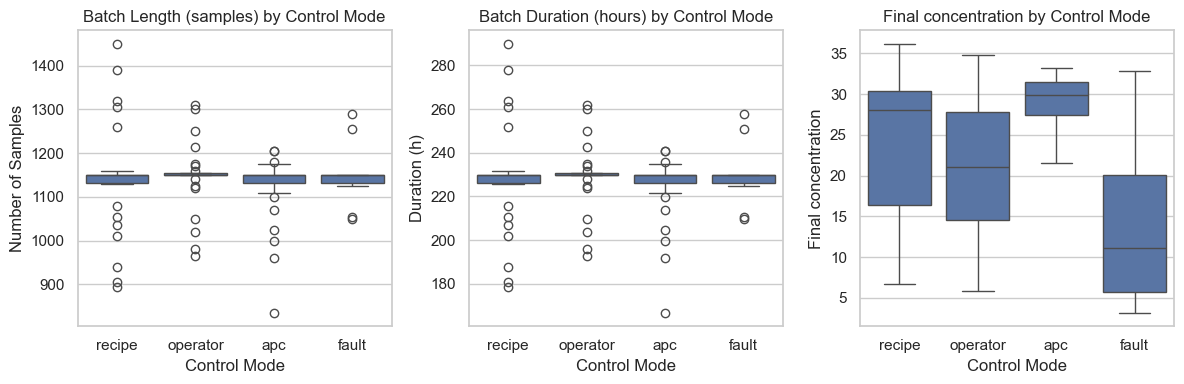

In [21]:
# Visualize batch lengths by control mode
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.boxplot(data=batch_info, x='control_mode', y='length', ax=axes[0])
axes[0].set_title('Batch Length (samples) by Control Mode')
axes[0].set_xlabel('Control Mode')
axes[0].set_ylabel('Number of Samples')

sns.boxplot(data=batch_info, x='control_mode', y='duration_h', ax=axes[1])
axes[1].set_title('Batch Duration (hours) by Control Mode')
axes[1].set_xlabel('Control Mode')
axes[1].set_ylabel('Duration (h)')

sns.boxplot(data=batch_info, x='control_mode', y='p_conc', ax=axes[2])
axes[2].set_title('Final concentration by Control Mode')
axes[2].set_xlabel('Control Mode')
axes[2].set_ylabel('Final concentration')

plt.tight_layout()
plt.savefig('../outputs/figures/batch_lengths.png', dpi=150)
plt.show()

In [22]:
# Check sampling rate (should be 0.2h = 12 min)
sample_batch = batches[1]
time_diffs = sample_batch['time'].diff().dropna()
print(f"Sampling interval: {time_diffs.mean():.2f}h (std: {time_diffs.std():.4f})")
print(f"Expected: 0.2h (12 minutes)")

Sampling interval: 0.20h (std: 0.0000)
Expected: 0.2h (12 minutes)


## 3. Missing Values and Anomalies

In [23]:
# Check missing values across all batches
all_data = pd.concat(batches.values(), ignore_index=True)
missing_pct = (all_data.isnull().sum() / len(all_data) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

Viscosity_offline    98.190196
X_offline            98.190196
NH3_offline          98.190196
P_offline            98.190196
PAA_offline          98.190196
dtype: float64

In [24]:
# Key input features for modeling
input_features = ['DO2', 'Fs', 'Fa', 'Fb', 'Fg', 'T', 'pH', 'RPM', 'CO2outgas', 'OUR', 'Fpaa']
target_features = ['P', 'P_offline']

# Check missing values in input features
available_inputs = [f for f in input_features if f in all_data.columns]
print("Input features available:", available_inputs)
print("\nMissing values in inputs:")
print(all_data[available_inputs].isnull().sum())

Input features available: ['DO2', 'Fs', 'Fa', 'Fb', 'Fg', 'T', 'pH', 'RPM', 'CO2outgas', 'OUR', 'Fpaa']

Missing values in inputs:
DO2          0
Fs           0
Fa           0
Fb           0
Fg           0
T            0
pH           0
RPM          0
CO2outgas    0
OUR          0
Fpaa         0
dtype: int64


In [25]:
# Identify fault batches
fault_batches = batch_info[batch_info['is_fault']]
print(f"Fault batches: {fault_batches['batch_id'].tolist()}")
print(f"Total fault batches: {len(fault_batches)}")

Fault batches: [91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Total fault batches: 10


## 4. Representative Trajectories by Control Mode

In [26]:
def plot_trajectories(batches, batch_ids, variable, title, ax):
    """Plot trajectories for selected batches."""
    for bid in batch_ids:
        df = batches[bid]
        ax.plot(df['time'], df[variable], alpha=0.7, label=f'Batch {bid}')
    ax.set_xlabel('Time (h)')
    ax.set_ylabel(variable)
    ax.set_title(title)
    ax.legend(loc='best', fontsize=8)

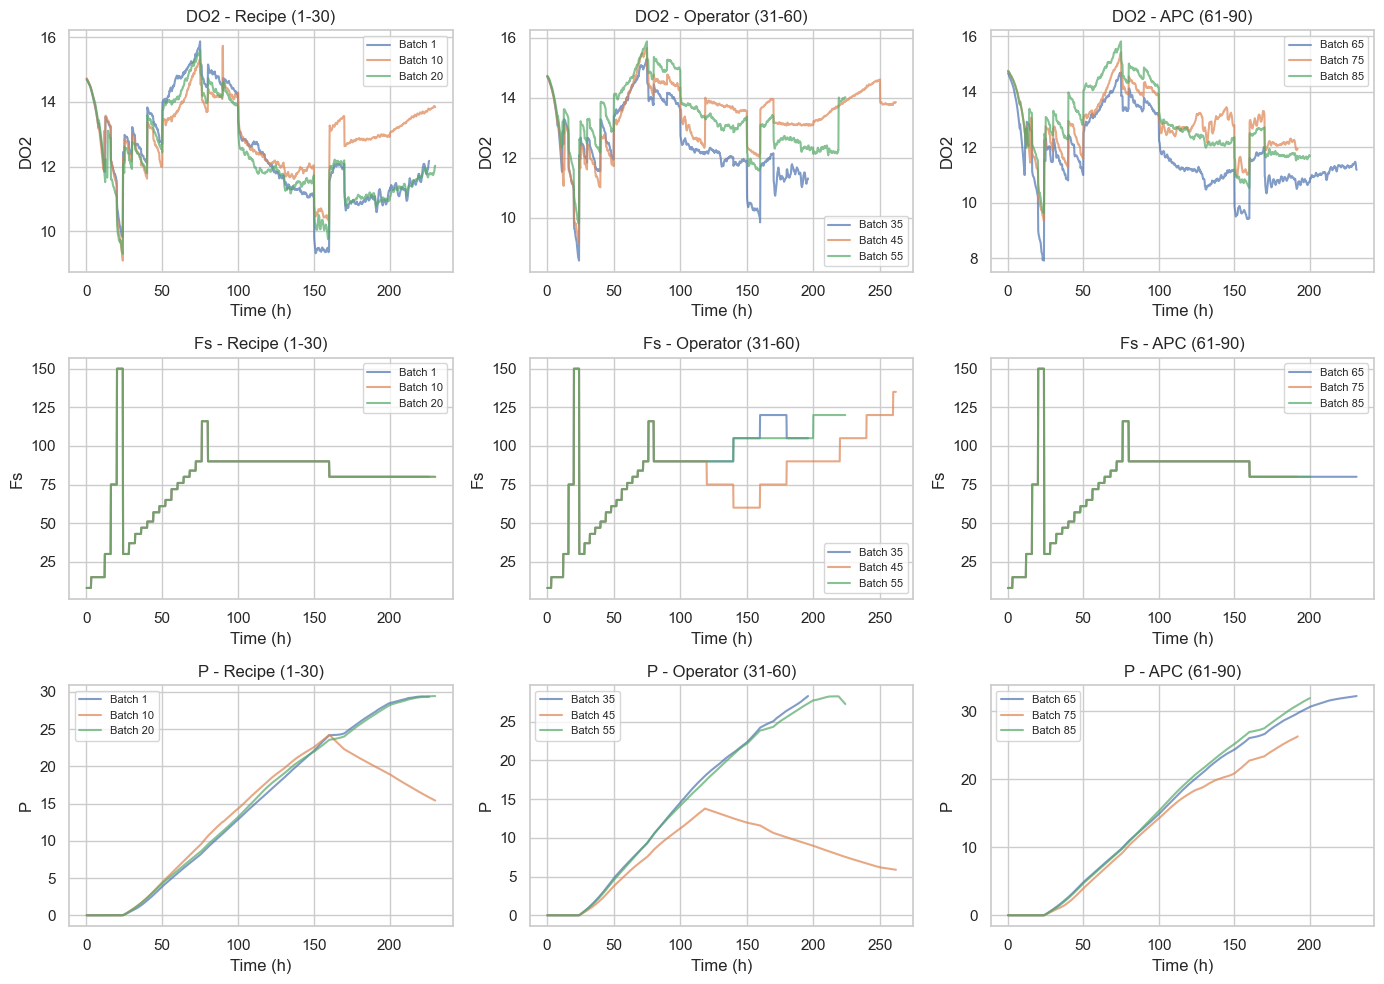

In [27]:
# Select representative batches from each control mode (excluding faults)
recipe_batches = [1, 10, 20]  # 1-30
operator_batches = [35, 45, 55]  # 31-60
apc_batches = [65, 75, 85]  # 61-90

variables_to_plot = ['DO2', 'Fs', 'P']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for i, var in enumerate(variables_to_plot):
    plot_trajectories(batches, recipe_batches, var, f'{var} - Recipe (1-30)', axes[i, 0])
    plot_trajectories(batches, operator_batches, var, f'{var} - Operator (31-60)', axes[i, 1])
    plot_trajectories(batches, apc_batches, var, f'{var} - APC (61-90)', axes[i, 2])

plt.tight_layout()
plt.savefig('../outputs/figures/trajectories_by_control.png', dpi=150)
plt.show()

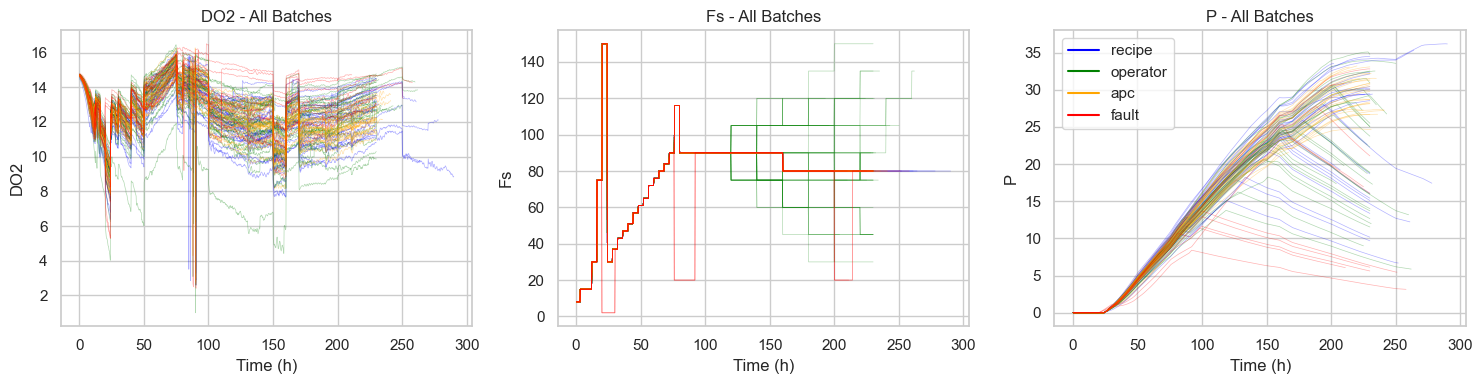

In [28]:
# Plot all batches for key variables (colored by control mode)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'recipe': 'blue', 'operator': 'green', 'apc': 'orange', 'fault': 'red'}

for var, ax in zip(['DO2', 'Fs', 'P'], axes):
    for bid, df in batches.items():
        mode = batch_info[batch_info['batch_id'] == bid]['control_mode'].values[0]
        ax.plot(df['time'], df[var], color=colors[mode], alpha=0.3, linewidth=0.5)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel(var)
    ax.set_title(f'{var} - All Batches')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, label=m) for m, c in colors.items()]
axes[2].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/figures/all_trajectories.png', dpi=150)
plt.show()

### Online vs Offline Penicillin Measurements

Compare continuous penicillin concentration (`P`) with 12-hour offline sampling (`P_offline`) to understand measurement differences.

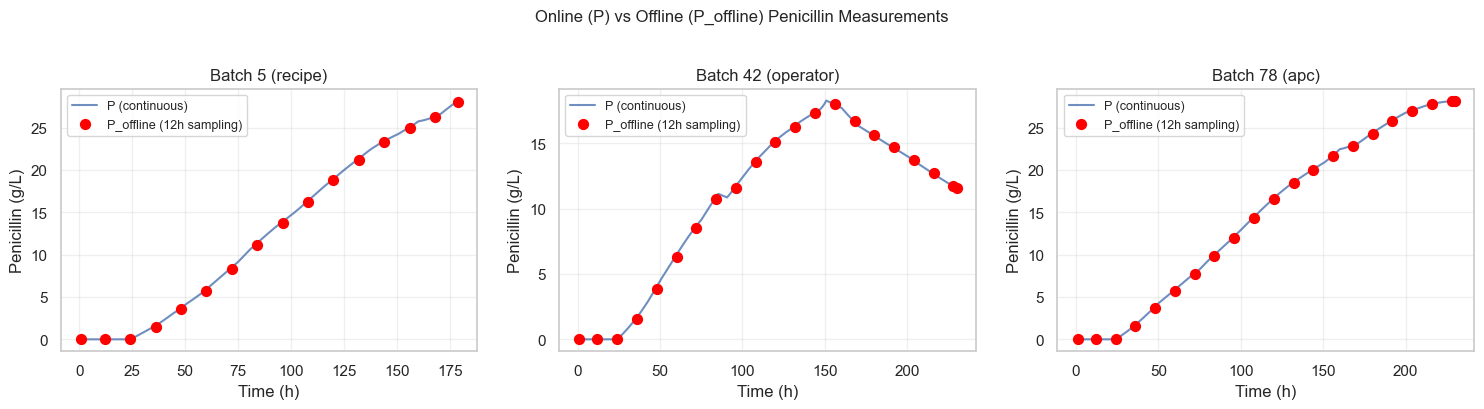

Offline sampling frequency:
  Batch 5: 11.9h avg interval (16 samples)
  Batch 42: 11.4h avg interval (21 samples)
  Batch 78: 11.4h avg interval (21 samples)


In [29]:
# Compare P (continuous) vs P_offline (12-hour sampling) for selected batches
# Edit this list to change which batches are displayed (valid range: 1-90)
comparison_batch_ids = [5, 42, 78]  # One from each control mode: recipe, operator, apc

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, bid in zip(axes, comparison_batch_ids):
    df = batches[bid]
    mode = batch_info[batch_info['batch_id'] == bid]['control_mode'].values[0]
    
    # Plot continuous P
    ax.plot(df['time'], df['P'], 'b-', linewidth=1.5, alpha=0.8, label='P (continuous)')
    
    # Plot P_offline (sparse 12-hour sampling) - only non-NaN values
    offline_mask = df['P_offline'].notna()
    ax.scatter(df.loc[offline_mask, 'time'], df.loc[offline_mask, 'P_offline'], 
               c='red', s=50, marker='o', zorder=5, label='P_offline (12h sampling)')
    
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Penicillin (g/L)')
    ax.set_title(f'Batch {bid} ({mode})')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Online (P) vs Offline (P_offline) Penicillin Measurements', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/P_vs_P_offline.png', dpi=150, bbox_inches='tight')
plt.show()

# Print sampling frequency for offline measurements
print("Offline sampling frequency:")
for bid in comparison_batch_ids:
    df = batches[bid]
    offline_times = df.loc[df['P_offline'].notna(), 'time'].values
    if len(offline_times) > 1:
        intervals = np.diff(offline_times)
        print(f"  Batch {bid}: {np.mean(intervals):.1f}h avg interval ({len(offline_times)} samples)")

## 5. Final Penicillin Distribution by Control Mode

In [30]:
# Get final penicillin concentration
final_p = get_final_penicillin(batches)
final_p = final_p.merge(batch_info[['batch_id', 'control_mode']], on='batch_id')
final_p.head()

,batch_id,final_P,control_mode
0,1,29.373,recipe
1,2,30.416,recipe
2,3,17.428,recipe
3,4,15.107,recipe
4,5,28.172,recipe


In [31]:
# Statistics by control mode
final_p.groupby('control_mode')['final_P'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
control_mode,,,,,,,,
apc,30.0,29.41,2.73,21.60,27.49,29.89,31.49,33.21
fault,10.0,14.42,10.97,3.16,5.74,11.10,20.07,32.80
operator,30.0,21.51,8.03,5.88,14.49,21.04,27.80,34.76
recipe,30.0,24.32,8.70,6.70,16.39,27.99,30.34,36.16


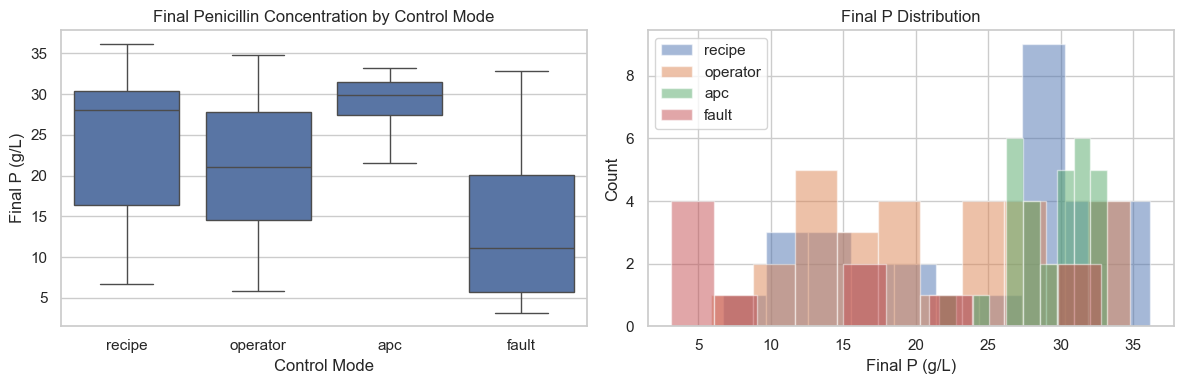

In [32]:
# Visualize final P distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot
sns.boxplot(data=final_p, x='control_mode', y='final_P', ax=axes[0])
axes[0].set_title('Final Penicillin Concentration by Control Mode')
axes[0].set_xlabel('Control Mode')
axes[0].set_ylabel('Final P (g/L)')

# Histogram
for mode in ['recipe', 'operator', 'apc', 'fault']:
    data = final_p[final_p['control_mode'] == mode]['final_P']
    axes[1].hist(data, bins=10, alpha=0.5, label=mode)
axes[1].set_title('Final P Distribution')
axes[1].set_xlabel('Final P (g/L)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/final_P_distribution.png', dpi=150)
plt.show()

## 6. Summary Statistics

In [33]:
# Load and display batch statistics
stats = load_statistics()
stats.head(10)

,batch_id,P_harvested_during,P_harvested_end,P_yield_total,is_fault
0,1,1066400.0,1720000.0,2786400.0,0
1,2,985910.0,1340100.0,2326000.0,0
2,3,1416100.0,1259200.0,2675300.0,0
3,4,815700.0,1071000.0,1886700.0,0
4,5,1128500.0,2434400.0,3562900.0,0
5,6,1005700.0,1383100.0,2388700.0,0
6,7,1147600.0,2307000.0,3454600.0,0
7,8,1201200.0,2676200.0,3877400.0,0
8,9,1757800.0,2325300.0,4083100.0,0
9,10,878430.0,1103600.0,1982000.0,0


In [34]:
# Summary
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total batches: {len(batches)}")
print(f"Fault batches (excluded): {len(fault_batches)}")
print(f"Valid batches: {len(batches) - len(fault_batches)}")
print(f"\nSampling rate: 0.2h (12 min)")
print(f"\nBatch lengths:")
print(batch_info.groupby('control_mode')['length'].agg(['min', 'max', 'mean']).round(0))
print(f"\nFinal P by control mode (g/L):")
print(final_p.groupby('control_mode')['final_P'].agg(['mean', 'std']).round(2))

EDA SUMMARY
Total batches: 100
Fault batches (excluded): 10
Valid batches: 90

Sampling rate: 0.2h (12 min)

Batch lengths:
               min   max    mean
control_mode                    
apc            835  1205  1123.0
fault         1050  1290  1152.0
operator       965  1310  1146.0
recipe         895  1450  1144.0

Final P by control mode (g/L):
               mean    std
control_mode              
apc           29.41   2.73
fault         14.42  10.97
operator      21.51   8.03
recipe        24.32   8.70


## Key Observations

1. **Batch structure**: 100 batches total, 10 fault batches (91-100) to exclude
2. **Sampling**: Consistent 0.2h (12 min) intervals
3. **Variable lengths**: APC batches tend to be longer than recipe/operator
4. **Domain differences**: Visible trajectory differences between control modes
5. **Target distribution**: Final P varies by control mode - potential domain shift